In [2]:
# Declare libraries
import json
import os
import pathlib
import time
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely

import requests
from requests.auth import HTTPBasicAuth
from planet import Session, DataClient, OrdersClient, Auth, Planet

# declare misc vars
crs = "EPSG:4326"
#crs = "EPSG:3310"
county_filepath = "/capstone/wildfire_prep/data/ca_counties/CA_Counties.shp"
# sb_bbox = [-125, 34.25, -119.0, 38.0]

data_api_url = "https://api.planet.com/data/v1"
orders_api_url = 'https://api.planet.com/compute/ops/orders/v2' 

# load CA county shps
counties = (
    gpd
    .read_file(county_filepath)
    .to_crs(crs)
    )

# isolate sb shp
sb_county = (
    counties
    .loc[counties["NAME"] == "Santa Barbara"]
    .explode(ignore_index=True) # separate mainland and islands
    .iloc[[0]] # select mainland
    )

Set api key and authorize

In [3]:
# if your Planet API Key is not set as an environment variable, you can paste it below
if os.environ.get('PL_API_KEY') == None:
    os.environ["PL_API_KEY"] = 'PLAK723f32b266fa484cb256071a3006e80b'
    
planet_key = os.environ.get("PL_API_KEY")

# authentication
auth = HTTPBasicAuth(planet_key, "")

# check we are communicating with http properly
response = requests.get(data_api_url, auth=auth)
print(response)

# make function for pagenation
def p(data):
    print(json.dumps(data, indent = 2))

<Response [200]>


init session

In [4]:
# setup
session = requests.Session()

# authenticate
session.auth = (planet_key, "")

res = session.get(data_api_url)

test polygon

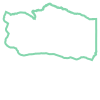

In [5]:
sb_county.boundary.iloc[0]

Declare splitting function

In [6]:
def split_equal_area(num_splits, polygon):

        # get triangle points from center

    # generate circle based on boundary
    circle = (
    shapely
    .minimum_bounding_circle(polygon)
    .buffer(abs(polygon.iloc[[0]].total_bounds[0]) + 
            abs(polygon.iloc[[0]].total_bounds[2]))
    )

    # get centroid of circle
    centerpoint = circle.centroid

    # add/reduce vertices to make the triangle segments (hopefully about) but less than this length
    bnd = circle.boundary.segmentize(500)

    # Extract the coordinates of all vertices of the segmentized boundary line
    boundary_coords = list(bnd[0].coords)




        # turn triangle coordinates into polygons

    # get area of sb poly
    original_area = polygon.area
    # get area of each resulting polygon of the split
    split_areas = original_area/num_splits

    polygon_slices = [] #Store the intersection result in a list

    # generate triangles
    # for vertex and vertex next to it
    for c1, c2 in zip(boundary_coords, boundary_coords[1:]):

        # init collection of points for each triangle
        circle_segment = shapely.MultiPoint([c1, c2, centerpoint[0]])

        # convex hull takes a collection of points and draws geometry by connecting the outside most points
        # in this case, it's connecting the points of the triangle together
        hull = circle_segment.convex_hull

        # clip the triangle to just the portion within sb county
        polygon_slices.append( hull.intersection(polygon) )



        # find optimal way to split polygon for most equal area

    # Calculate the area of each triangle minus the parts cut off with intersection
    polygon_slice_areas = [p.area for p in polygon_slices]

    # Calculate a walking cumulative area over every triangle
    slice_areas_cum = [float(x) for x in np.cumsum(polygon_slice_areas)] 

    # Calculate the optimal cumulative area
    optimal_cumulative_areas = [float(x) for x in np.cumsum([split_areas]*(num_splits-1))] 




        # Find the optimal indices to divide the polygon slices

    # init result
    best_indices_to_split = [0]

    # for each area of the split polygons
    for optimal_area in optimal_cumulative_areas:

        # subtract the cumulative area of the triangles from each polygon
        diffs = [abs(optimal_area-x) for x in slice_areas_cum]

        # find index of lowest discrepency between total split area
        best_split_index = diffs.index(min(diffs))

        # append it to the above list
        best_indices_to_split.append(best_split_index)

    # append the length of polygon vertices list for some reason
    best_indices_to_split.append(len(boundary_coords))




        # Create split polygons

    # init polygon slice list
    geometry_parts = []

    # union based on window of indices (ex: union triangles [0:500])
    for i1, i2 in zip(best_indices_to_split, best_indices_to_split[1:]):

        # union trianges from index i1 to index i2
        geometry_parts.append(shapely.ops.unary_union(polygon_slices[i1:i2]))

    # convert to geopandas obj
    split_geom = gpd.GeoSeries(geometry_parts)



    # Plot the result
    ax2 = (
        polygon
        .boundary
        .plot(
            figsize=(10, 10), 
            color="black", 
            zorder=2, 
            linewidth=10
            )
        )
    split_geom.plot(ax=ax2, cmap="Accent", zorder=1)
    for part in split_geom:
        part_area_prc = round(100*part.area/original_area, 2)
        x, y = part.centroid.xy
        x = x[0]
        y = y[0]
        #Annotate each slice with the relative area
        ax2.annotate(f"{part_area_prc} %", xy=(x, y), fontsize=15)



    return split_geom

simplify and split county polygon

In [7]:
gpd.GeoDataFrame(first_split)#.set_geometry(0).rename_geometry("geometry")

NameError: name 'first_split' is not defined

/tmp/ipykernel_1351218/3668350518.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  original_area = polygon.area


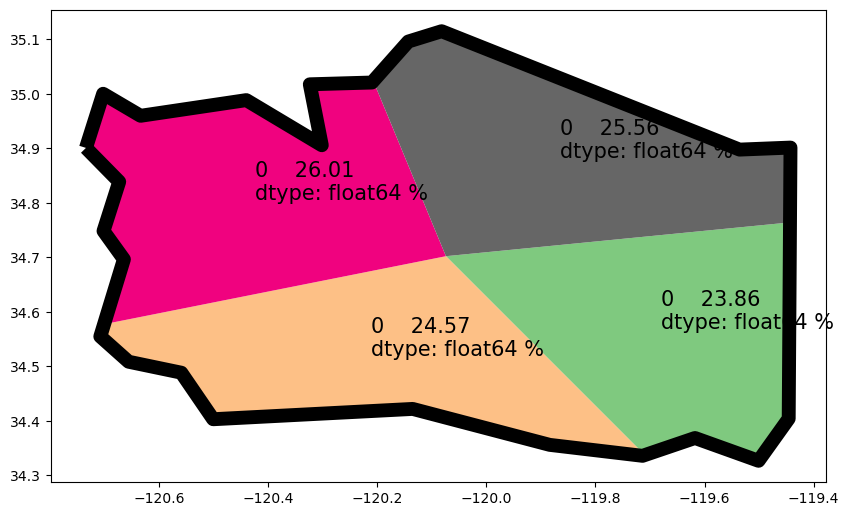

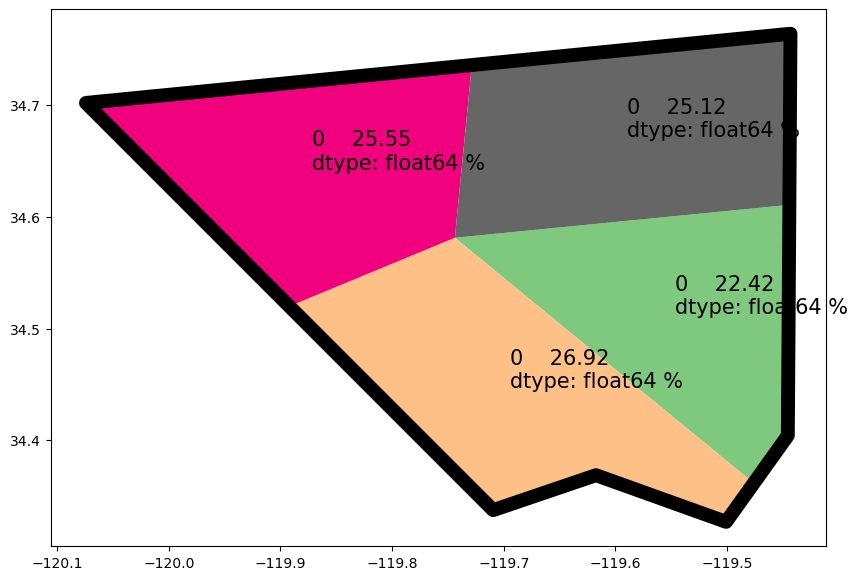

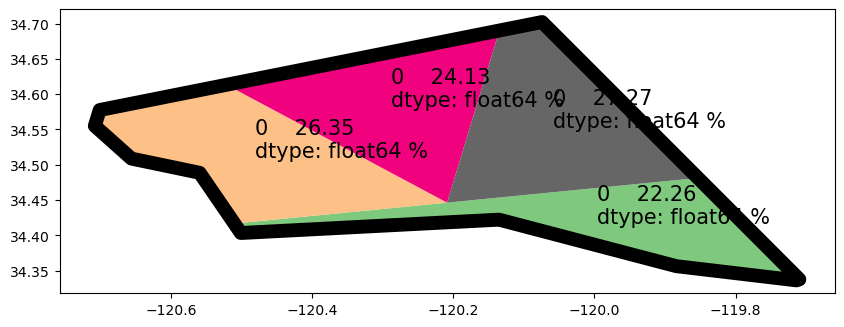

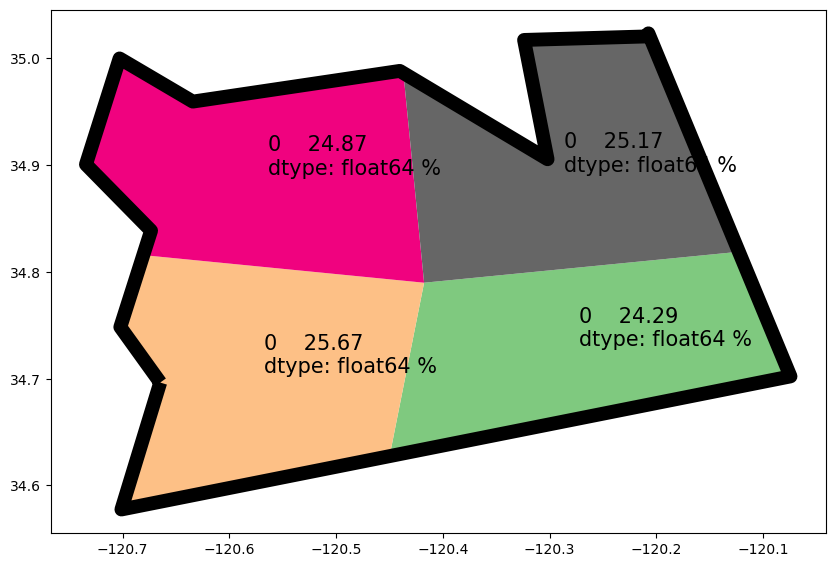

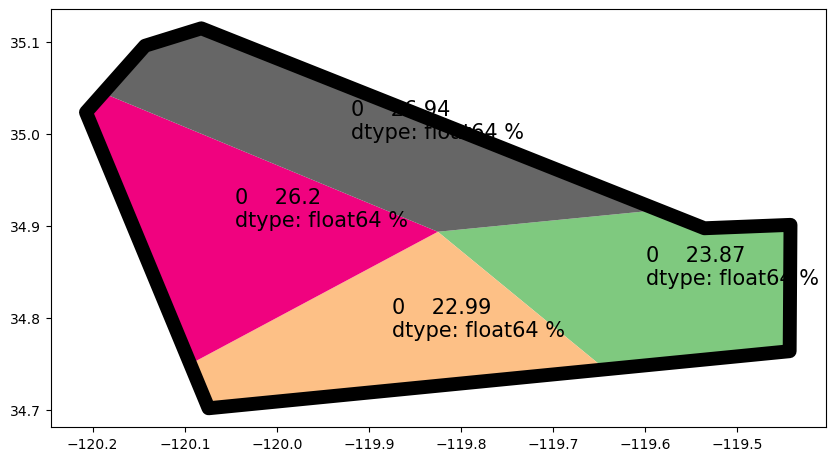

In [8]:
sb_simple = (
    sb_county 
    .simplify(0.02) # reduce number of verticies
    .to_frame(name="geometry") # convert back to gdf
    )

# split the sb boundary polygon
first_split = split_equal_area(4, sb_simple)

# reformat to prepare for second split
first_split_format = (
    gpd.GeoDataFrame(first_split) # reconvert back to gdf
    .set_geometry(0) # tell python where the geometry col is
    .rename_geometry("geometry") # rename this col
    )

# assign each side's polygon to their respective variables (right, bottom, left, top)
split_r_var = first_split_format.iloc[[0]].reset_index(drop = True)
split_b_var = first_split_format.iloc[[1]].reset_index(drop = True)
split_l_var = first_split_format.iloc[[2]].reset_index(drop = True)
split_t_var = first_split_format.iloc[[3]].reset_index(drop = True)

# split again on those variables
second_split_r = split_equal_area(4, split_r_var)
second_split_b = split_equal_area(4, split_b_var)
second_split_l = split_equal_area(4, split_l_var)
second_split_t = split_equal_area(4, split_t_var)

# attach all geometry rows into single geoseries
all_splits = (
    pd.concat(
        [
            second_split_r, 
            second_split_b, 
            second_split_l, 
            second_split_t
        ]
        )

    # give unique index val for each poly
    .reset_index(drop = True)
    )

In [9]:
all_splits

0     POLYGON ((-119.4453 34.4577, -119.44541 34.441...
1     POLYGON ((-119.79266 34.42055, -119.80525 34.4...
2     POLYGON ((-119.93471 34.5626, -119.95348 34.58...
3     POLYGON ((-119.69592 34.73927, -119.6777 34.74...
4     POLYGON ((-120.51011 34.41642, -120.51019 34.4...
5     POLYGON ((-120.53645 34.45489, -120.53662 34.4...
6     POLYGON ((-120.43347 34.63066, -120.39992 34.6...
7     POLYGON ((-120.01351 34.64141, -119.99433 34.6...
8     POLYGON ((-120.40241 34.63684, -120.40246 34.6...
9     POLYGON ((-120.68128 34.64216, -120.68117 34.6...
10    POLYGON ((-120.67589 34.84127, -120.71362 34.8...
11    POLYGON ((-120.35614 34.93804, -120.34265 34.9...
12    POLYGON ((-119.44327 34.76445, -119.44327 34.7...
13    POLYGON ((-119.97452 34.71191, -119.97463 34.7...
14    POLYGON ((-120.16756 34.92744, -120.16761 34.9...
15    POLYGON ((-119.90593 35.04468, -119.89382 35.0...
dtype: geometry

get geojson

In [10]:
# craft json making function
def declare_jsons(polygon):

    # function will simplify until polygons are this number of vertices
    num_verts = 31
    # starting simplification value for `gpd.simplify`
    simplify_val = 0.001

    # run loop again and again until polygon < 30 verts
    while num_verts > 30:
        sb_json = (
            gpd.GeoSeries(polygon).simplify(simplify_val).to_frame(name="geometry")
            .to_geo_dict() # convert polygon to geojson format
            ["features"][0] # select first and only feature
            ["geometry"] # select geometry attribute
        )

        # get number of vertices
        num_verts = len(sb_json["coordinates"][0])

        # increase amount of simplification by given rate
        simplify_val = simplify_val * 1.5


    print(f"Number of verticies: {num_verts}")

    return sb_json

In [11]:
# make list of variables names: "all_splits_i", one for each polygon
json_list = [f"all_splits_{i}" for i in range(len(all_splits))]

# declare the "all_splits_i" variables for each poly
for i in range(len(json_list)):
    vars()[json_list[i]] = declare_jsons(all_splits[i])

Number of verticies: 5
Number of verticies: 7
Number of verticies: 5
Number of verticies: 5
Number of verticies: 8
Number of verticies: 8
Number of verticies: 5
Number of verticies: 5
Number of verticies: 5
Number of verticies: 7
Number of verticies: 9
Number of verticies: 8
Number of verticies: 7
Number of verticies: 5
Number of verticies: 5
Number of verticies: 7


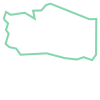

In [12]:
sb_county.simplify(0.02).to_frame(name="geometry").boundary.iloc[0]

Set filters

In [13]:
# make variable name list for each poly
geom_filter_list = [f"geometry_filter_{i}" for i in range(len(json_list))]

# declare variables with each name in list
for i in range(len(geom_filter_list)):
    vars()[geom_filter_list[i]] = {
        "type": "GeometryFilter", # set filter type as geometry
        "field_name": "geometry", # give json column containing geometry
        "config": vars()[f"all_splits_{i}"] # input sb county json for each polygon var
    }


# # set date filter
# date_range_filter = {
#     "type": "DateRangeFilter", 
#     "field_name": "acquired",  
#     "config": { 
#         "gte": "2018-01-01T00:00:00.000Z",
#         "lt":  "2024-01-01T00:00:00.000Z"
#     }
# }

# DEMO DATE RANGE FILTER
# ONLY FOR ONE MONTH
date_range_filter = {
    "type": "DateRangeFilter", 
    "field_name": "acquired",  # selects for when imagery was measured, not published
    "config": { 
        "gte": "2022-05-01T00:00:00.000Z", # greater then equal to
        "lt":  "2022-06-01T00:00:00.000Z" # less then
    }
}

# # set cloud cover filter
# cloud_cover_filter = {
#     "type": "RangeFilter", 
#     "field_name": "cloud_cover", 
#     "config": {
#         "lt": 0.5
#     }
# }

# MAKING CLOUD FILTER STRICTER TO MAKE NUM SCENES UNDER 500
cloud_cover_filter = {
    "type": "RangeFilter", # generalized filter type that takes range of values
    "field_name": "cloud_cover", # ask for cloud cover
    "config": {
        "lt": 0.01 # filter for all scenes w <1% cloud cover
    }
}


# make list of variable names for combined filters for each polygon
combined_filter_list = [f"combined_filters_{i}" for i in range(len(all_splits))]

# declare variables for each name in list (for each polygon)
for i in range(len(combined_filter_list)): 
    vars()[combined_filter_list[i]] = {
        "type": "AndFilter", 
        "config": [vars()[f"geometry_filter_{i}"], date_range_filter, cloud_cover_filter]
    }

In [14]:
combined_filters_0

{'type': 'AndFilter',
 'config': [{'type': 'GeometryFilter',
   'field_name': 'geometry',
   'config': {'type': 'Polygon',
    'coordinates': (((-119.44428590106276, 34.610827996449764),
      (-119.44565241492683, 34.404261824966895),
      (-119.47615676408086, 34.36161264531696),
      (-119.74384975709151, 34.58136700776197),
      (-119.44428590106276, 34.610827996449764)),)}},
  {'type': 'DateRangeFilter',
   'field_name': 'acquired',
   'config': {'gte': '2022-05-01T00:00:00.000Z',
    'lt': '2022-06-01T00:00:00.000Z'}},
  {'type': 'RangeFilter',
   'field_name': 'cloud_cover',
   'config': {'lt': 0.01}}]}

Run quick search based on filters

In [15]:
def quick_search(filters):

    # defines package type
    # PSScene has orthorectified 8 and 4 band imagery with the udm2 file
    # you can take imagery from multiple types but we only need this one
    item_types = ["PSScene"]

    # feed our filters and package type selection into a filter dict
    search_request = {
        "item_types": item_types,
        "filter": filters
    }

    # and we search Planet labs imagery with it
    search_result = \
        requests.post( # post sends our request to https api
            "https://api.planet.com/data/v1/quick-search",
            auth = HTTPBasicAuth(planet_key, ''), # we give it our key
            json = search_request # and our request dict
        )

    print(search_result)

    return search_result

search_result_0 = quick_search(combined_filters_0)
search_result_1 = quick_search(combined_filters_1)
search_result_2 = quick_search(combined_filters_2)
search_result_3 = quick_search(combined_filters_3)

<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>


In [16]:
# result of first search result
json.loads(search_result_0.text)

{'_links': {'_first': 'https://api.planet.com/data/v1/searches/568e4e64d3174f948c7594efae88376c/results?_page=eyJwYWdlX3NpemUiOiAyNTAsICJzb3J0X2J5IjogInB1Ymxpc2hlZCIsICJzb3J0X2Rlc2MiOiB0cnVlLCAic29ydF9zdGFydCI6IG51bGwsICJzb3J0X2xhc3RfaWQiOiBudWxsLCAic29ydF9wcmV2IjogZmFsc2UsICJxdWVyeV9wYXJhbXMiOiB7fX0%3D',
  '_next': 'https://api.planet.com/data/v1/searches/568e4e64d3174f948c7594efae88376c/results?_page=eyJwYWdlX3NpemUiOiAyNTAsICJzb3J0X2J5IjogInB1Ymxpc2hlZCIsICJzb3J0X2Rlc2MiOiB0cnVlLCAic29ydF9zdGFydCI6ICIyMDIyLTA1LTA0VDAzOjI4OjEyLjAwMDAwMFoiLCAic29ydF9sYXN0X2lkIjogIjIwMjIwNTAzXzE4MjAxM184MV8yNDk5IiwgInNvcnRfcHJldiI6IGZhbHNlLCAicXVlcnlfcGFyYW1zIjoge319',
  '_self': 'https://api.planet.com/data/v1/searches/568e4e64d3174f948c7594efae88376c/results?_page=eyJwYWdlX3NpemUiOiAyNTAsICJzb3J0X2J5IjogInB1Ymxpc2hlZCIsICJzb3J0X2Rlc2MiOiB0cnVlLCAic29ydF9zdGFydCI6IG51bGwsICJzb3J0X2xhc3RfaWQiOiBudWxsLCAic29ydF9wcmV2IjogZmFsc2UsICJxdWVyeV9wYXJhbXMiOiB7fX0%3D'},
 'features': [{'_links': {'_self': 'https:

Print first 250 scene ids

In [18]:
# first_ids = [feature['id'] for feature in search_result.json()["features"]]
# first_ids

Print all scene ids

In [ ]:
def get_ids(search_result):

    # get all ids from first url
    first_ids = [feature['id'] for feature in search_result.json()["features"]]
    
    # attach the first ids to a list
    all_ids = []
    all_ids.extend(first_ids)

    # if this value is lower than 250 (the max num of ids per url), loop below will not activate
    loop_trigger = len(first_ids)

    # turn inputted search result into a json/dict
    id_json = search_result.json()

    # loop will repeat for current url containing the max number of urls
    while loop_trigger == 250:

         # get next url in the search result
        next_url = id_json["_links"]["_next"]

        # make request for the next 250 scenes from that next url
        next_250 = session.get(next_url)
        
        # turn that search into a json
        id_json = next_250.json()

        # extract scene data
        features = id_json["features"]


        # init list to contain this iteration of the 250 scenes
        id_list = []

        for f in features:
            
            # get id for each feature, attach it to list
            id_str = f["id"]
            id_list.extend([id_str])

        # append current iteration list to the master list
        all_ids.extend(id_list)

        # print the total number of scenes obtained from search up to this point
        print(f"num ids: {len(all_ids)}")

        # trigger to end loop once all scenes of the iteration have been attached
        loop_trigger = len(id_list)
    
    return all_ids

ids_0 = get_ids(search_result_0)
ids_1 = get_ids(search_result_1)
ids_2 = get_ids(search_result_2)
ids_3 = get_ids(search_result_3)

# attach all id lists together
all_ids = []
for ids in [ids_0, ids_1, ids_2, ids_3]:
    all_ids.extend(ids)

In [76]:
print(f"Right poly num of ids: {len(ids_0)}")
print(f"Bottom poly num of ids: {len(ids_1)}")
print(f"Left poly num of ids: {len(ids_2)}")
print(f"Top poly num of ids: {len(ids_3)}")

Right poly num of ids: 96
Bottom poly num of ids: 99
Left poly num of ids: 138
Top poly num of ids: 111


In [22]:
# not_str_cnt = 0
# for id in all_ids:
#     if isinstance(id, str) != True:
#         print(f"{id} not string!!")
#         not_str_cnt = not_str_cnt + 1

# print(f"not string count: {not_str_cnt}")

### Requests example

In this notebook, we will be using `requests` to communicate with the orders v2 API. First, we will check our orders list to make sure authentication and communication is working as expected.

We want to get a response code of `200` from this API call. To troubleshoot other response codes, see the [List Orders](https://developers.planet.com/apis/orders/reference/#tag/Orders/operation/listOrders) API reference.

In [23]:
# init auth with key again
auth = HTTPBasicAuth(planet_key, "")

# test that we are communicating with api successfully
order_response = requests.get(orders_api_url, auth=auth)
print(order_response)

<Response [200]>


Print previous orders

In [77]:
# get all orders
orders = order_response.json()['orders']

# print past 10 orders
[r['name'] for r in orders[:10]]

['wildfire_single_scene_test1',
 'wildfire_250_scene_test1',
 'wildfire_50_scene_test1',
 'wildfire_10_scene_test1',
 'wildfire_single_scene_test1',
 'wildfire_imagery_top',
 'wildfire_imagery_left',
 'wildfire_imagery_bottom',
 'wildfire_imagery_right',
 'wildfire_prep_dataset_test2']

Make order request

In [ ]:
# set content type to json
headers = {"content-type": "application/json"}

def order_setup(ids, name_extention):

    # init order parameters
    product = [
        { 
            "item_ids": ids, 
            "item_type": "PSScene", 
            "product_bundle": "analytic_8b_sr_udm2", # ortho 8 band with udm2
        }
    ]

    order_request = {
        "name": f"wildfire_imagery_{name_extention}", 
        "products": product, 
        "delivery": {"single_archive": True, # archive all bundles together in single file
                     "archive_type": "zip"} # get zip folder
    }

    return order_request, product

order_request_0, product_0 = order_setup(ids_0, "right")
order_request_1, product_1 = order_setup(ids_1, "bottom")
order_request_2, product_2 = order_setup(ids_2, "left")
order_request_3, product_3 = order_setup(ids_3, "top")

In [ ]:
# gets link to status of the "wildfire_imagery_left" order
test_id = orders_api_url + '/' + "b09097d5-2724-480b-8646-a29d0424ccd0"
print(test_id)

https://api.planet.com/compute/ops/orders/v2/b09097d5-2724-480b-8646-a29d0424ccd0


In [373]:
def place_order(request, auth):

    # make order request
    response = requests.post(
        orders_api_url, 
        data = json.dumps(request), 
        auth = auth, 
        headers = headers
        )
    print(response.json())

    # get ids of scenes
    order_id = response.json()["id"]
    print(order_id)

    # construct the url of our order
    order_url = orders_api_url + '/' + order_id
    
    return order_url

### Clip to Santa Barbara County

In [ ]:
def init_clip(json, product):
    # init clip parameters
    clip =  {
        "clip": {
            "aoi": json
        }
    }



    clip_request = { 
        "name": "wildfire santa barbara", 
        "products": product, 
        "tools": [clip], 
        "delivery": {"single_archive": True, "archive_type": "zip"}
    }

    return clip_request

clip_request_0 = init_clip(sb_json_0, product_0)
clip_request_1 = init_clip(sb_json_1, product_1)
clip_request_2 = init_clip(sb_json_2, product_2)
clip_request_3 = init_clip(sb_json_3, product_3)

##### Place order and check for order success

In [ ]:
# we don't have permission to run the clip tool
# clip_order_url_0 = place_order(clip_request_0, auth)
# clip_order_url_1 = place_order(clip_request_1, auth)
# clip_order_url_2 = place_order(clip_request_2, auth)
# clip_order_url_3 = place_order(clip_request_3, auth)

{'field': None, 'general': [{'message': "Unable to accept order: Your organization does not have permission to run the 'clip' tool"}]}


KeyError: 'id'

In [65]:
# requests.post(
#         orders_api_url, 
#         data = json.dumps(clip_request), 
#         auth = auth, 
#         headers = headers
#         ).json()

In [66]:
#print(json.dumps(clip_request, indent = 4))

In [379]:
# clip tool still doesn't work, so I'll just order normally for now
# order_url = place_order(order_request, auth)

order_url_0 = place_order(order_request_0, auth)
order_url_1 = place_order(order_request_1, auth)
order_url_2 = place_order(order_request_2, auth)
order_url_3 = place_order(order_request_3, auth)

{'_links': {'_self': 'https://api.planet.com/compute/ops/orders/v2/6210c7df-cca7-4f37-a7fb-872144454698'}, 'created_on': '2025-04-08T10:17:13.87387Z', 'delivery': {'archive_filename': 'output.zip', 'archive_type': 'zip', 'single_archive': True}, 'error_hints': [], 'id': '6210c7df-cca7-4f37-a7fb-872144454698', 'last_message': 'Preparing order', 'last_modified': '2025-04-08T10:17:13.87387Z', 'name': 'wildfire_imagery_right', 'products': [{'item_ids': ['20220528_181835_24_2484', '20220528_181832_96_2484', '20220524_181016_82_2231', '20220524_181014_61_2231', '20220520_181316_23_2231', '20220505_174909_18_220b', '20220524_182146_44_2446', '20220501_182002_84_249a', '20220501_182000_56_249a', '20220501_181958_29_249a', '20220501_181956_01_249a', '20220501_181953_74_249a', '20220502_174952_86_245c', '20220502_174950_58_245c', '20220503_183314_17_227a', '20220503_183311_89_227a', '20220503_183309_61_227a', '20220503_183307_32_227a', '20220531_183407_26_240a', '20220531_174839_43_2448', '20220

### Poll for order success

In [365]:
def poll_for_success(order_url, auth, num_loops = 30): 
    i = 0
    while(i < num_loops): 

        # iterate
        i += 1

        # get order request
        r = requests.get(order_url, auth = auth)
        response = r.json()

        # grab current state
        state = response["orders"][0]["state"]
        print(state)

        # compare it to a variety of end states and print it
        end_states = ["success", "failed", "partial"]
        if state in end_states:
            print(f"End State: {state}")
            break

        # wait 30 secs
        time.sleep(30)

# poll_for_success(orders_api_url, auth)

In [69]:
# test = requests.get(orders_api_url, auth = auth).json()
# test["orders"][0]["state"]

In [ ]:
# we don't have permission to run the clip tool
poll_for_success(clip_order_url, auth)

View current results of order

once, without needing to run the function

In [225]:
r = requests.get(orders_api_url, auth = auth)
clip_response = r.json()
order_results = clip_response["orders"][0]["state"]
order_results

'running'

### download

In [ ]:
Planet().orders.download_order(
    response["orders"][0]["id"], # get order id
    overwrite = False, # don't overwrite files that already exist
    directory = "/data/wildfire_prep" # set directory to our data folder in workbench-2
    )

##### depreciated/nonfunctional

In [ ]:
# # download results locally and individually
# def download_results(results, overwrite=False):
#     results_urls = [r['location'] for r in results]
#     results_names = [r['name'] for r in results]
#     print('{} items to download'.format(len(results_urls)))
    
#     for url, name in zip(results_urls, results_names):
#         path = pathlib.Path(os.path.join('..', '..', '..', 'data', name))
        
#         if overwrite or not path.exists():
#             print('downloading {} to {}'.format(name, path))
#             r = requests.get(url, allow_redirects=True)
#             path.parent.mkdir(parents=True, exist_ok=True)
#             open(path, 'wb').write(r.content)
#         else:
#             print('{} already exists, skipping {}'.format(path, name))

In [ ]:
# download_results(order_results)